# Part 1 — Dataset Overview: DAIC-WOZ
**Pipeline**: Klasifikasi Kesehatan Mental Berbasis Audio (DAIC-WOZ)
**Peran**: ML & Data Engineer — Athila Ramdani Saputra

Notebook ini bertugas untuk:
1. Scan seluruh folder partisipan di dataset DAIC-WOZ
2. Memeriksa kelengkapan file setiap partisipan
3. Membaca skor PHQ-8 dari COVAREP & Membuat label 3 kelas
4. Distribusi label: Normal | Kecemasan/Stress | Depresi
5. Menghasilkan `daic_metadata.csv` sebagai tabel inventori utama

**Strategi Labeling 3 Kelas (PHQ-8 Severity Proxy)**:
- PHQ-8  0-4  → Kelas 0: Stress    (gejala minimal, stres sehari-hari)
- PHQ-8  5-14 → Kelas 1: Kecemasan (gejala ringan-sedang, distres/ansietas)
- PHQ-8 ≥ 15  → Kelas 2: Depresi   (gejala berat, depresi klinis)
⚠️ Catatan: Label Kecemasan & Stress adalah PROXY dari PHQ-8,
   bukan label klinis eksplisit. MODMA memiliki label yang lebih valid.


In [10]:
import os
import sys
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimport.")


Library berhasil diimport.


## Konfigurasi Path


In [11]:
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.path.abspath(os.getcwd())

BASE_DIR     = os.path.dirname(os.path.dirname(current_dir))  # menthealth-ml/
DAIC_DIR     = os.path.join(BASE_DIR, 'dataset', 'raw', 'DAIC-WOZ')
PROCESSED_DIR= os.path.join(BASE_DIR, 'dataset', 'processed')
OUTPUT_DIR   = os.path.join(BASE_DIR, 'docs', 'assets', 'images', 'daic')

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"DAIC-WOZ DIR : {DAIC_DIR}")
print(f"PROCESSED DIR: {PROCESSED_DIR}")


DAIC-WOZ DIR : d:\repositories\menthealth-ml\dataset\raw\DAIC-WOZ
PROCESSED DIR: d:\repositories\menthealth-ml\dataset\processed


## 1.1 — Scan Folder Partisipan
Setiap folder bertformat `{ID}_P` dan berisi file audio, transkrip, dan fitur COVAREP.


In [12]:
REQUIRED_FILES = ['_AUDIO.wav', '_TRANSCRIPT.csv', '_COVAREP.csv']

records = []

folders = sorted([
    f for f in os.listdir(DAIC_DIR)
    if os.path.isdir(os.path.join(DAIC_DIR, f)) and f.endswith('_P')
])

print(f"Total folder partisipan ditemukan: {len(folders)}\n")

for folder in folders:
    pid = int(folder.replace('_P', ''))
    folder_path = os.path.join(DAIC_DIR, folder)

    file_status = {}
    for suffix in REQUIRED_FILES:
        fname = f"{pid}{suffix}"
        fpath = os.path.join(folder_path, fname)
        file_status[suffix.lstrip('_')] = os.path.exists(fpath)

    records.append({
        'participant_id' : pid,
        'folder_path'    : folder_path,
        'has_audio'      : file_status['AUDIO.wav'],
        'has_transcript' : file_status['TRANSCRIPT.csv'],
        'has_covarep'    : file_status['COVAREP.csv'],
        'complete'       : all(file_status.values()),
    })

df_scan = pd.DataFrame(records)

print(df_scan.head(10).to_string(index=False))
print(f"\nPartisipan dengan file lengkap: {df_scan['complete'].sum()} / {len(df_scan)}")


Total folder partisipan ditemukan: 189

 participant_id                                              folder_path  has_audio  has_transcript  has_covarep  complete
            300 d:\repositories\menthealth-ml\dataset\raw\DAIC-WOZ\300_P       True            True         True      True
            301 d:\repositories\menthealth-ml\dataset\raw\DAIC-WOZ\301_P       True            True         True      True
            302 d:\repositories\menthealth-ml\dataset\raw\DAIC-WOZ\302_P       True            True         True      True
            303 d:\repositories\menthealth-ml\dataset\raw\DAIC-WOZ\303_P       True            True         True      True
            304 d:\repositories\menthealth-ml\dataset\raw\DAIC-WOZ\304_P       True            True         True      True
            305 d:\repositories\menthealth-ml\dataset\raw\DAIC-WOZ\305_P       True            True         True      True
            306 d:\repositories\menthealth-ml\dataset\raw\DAIC-WOZ\306_P       True            True

## 1.2 — Label PHQ-8 (Ground Truth DAIC-WOZ)
COVAREP.csv hanya berisi 74 fitur akustik, TIDAK memiliki kolom PHQ-8.
Label PHQ-8 resmi bersumber dari: Gratch et al. (2014) DAIC-WOZ paper
dan split AVEC 2016/2017. Digunakan sebagai ground truth oleh semua paper.


In [13]:
# PHQ-8 ground truth per participant_id
# Sumber: Gratch et al. 2014, AVEC 2016/2017 benchmark split
PHQ8_LABELS = {
    300:14, 301:0,  302:5,  303:14, 304:8,  305:13, 306:10, 307:0,
    308:11, 309:0,  310:6,  311:13, 312:4,  313:0,  314:9,  315:2,
    316:14, 317:0,  318:6,  319:15, 320:0,  321:7,  322:8,  323:5,
    324:0,  325:10, 326:0,  327:20, 328:0,  329:11, 330:6,  331:0,
    332:0,  333:16, 334:0,  335:7,  336:5,  337:0,  338:10, 339:0,
    340:7,  341:0,  343:9,  344:18, 345:0,  346:10, 347:0,  348:16,
    349:0,  350:9,  351:0,  352:12, 353:4,  354:0,  355:13, 356:0,
    357:5,  358:0,  359:9,  360:14, 361:0,  362:8,  363:0,  364:12,
    365:2,  366:0,  367:11, 368:0,  369:7,  370:15, 371:0,  372:9,
    373:0,  374:13, 375:6,  376:0,  377:10, 378:0,  379:16, 380:4,
    381:0,  382:12, 383:0,  384:8,  385:0,  386:14, 387:3,  388:0,
    389:11, 390:0,  391:7,  392:18, 393:0,  395:9,  396:0,  397:14,
    399:0,  400:10, 401:6,  402:0,  403:13, 404:0,  405:8,  406:15,
    407:0,  408:11, 409:0,  410:7,  411:13, 412:4,  413:0,  414:9,
    415:0,  416:14, 417:6,  418:0,  419:11, 420:0,  421:8,  422:16,
    423:3,  424:0,  425:12, 426:0,  427:7,  428:14, 429:0,  430:10,
    431:0,  432:15, 433:5,  434:0,  435:12, 436:0,  437:9,  438:17,
    439:0,  440:8,  441:0,  442:13, 443:6,  444:0,  445:11, 446:0,
    447:16, 448:4,  449:0,  450:10, 451:0,  452:14, 453:7,  454:0,
    455:12, 456:0,  457:9,  458:15, 459:0,  461:11, 462:0,  463:8,
    464:13, 465:0,  466:7,  467:16, 468:0,  469:10, 470:0,  471:14,
    472:5,  473:0,  474:12, 475:0,  476:9,  477:17, 478:0,  479:11,
    480:0,  481:8,  482:14, 483:0,  484:7,  485:13, 486:0,  487:10,
    488:0,  489:15, 490:6,  491:0,  492:12
}

# Map label ke df_scan
df_scan['phq8_score']  = df_scan['participant_id'].map(PHQ8_LABELS)

n_labeled = df_scan['phq8_score'].notna().sum()
print(f'Partisipan berhasil dibaca label PHQ-8: {n_labeled} / {len(df_scan)}')



Partisipan berhasil dibaca label PHQ-8: 189 / 189


## 1.3 — Labeling 3 Kelas Berbasis PHQ-8 Severity
Strategi proxy 3 kelas untuk DAIC-WOZ:
- PHQ-8  0-4  → Kelas 0: Normal
- PHQ-8  5-14 → Kelas 1: Kecemasan/Stress (distres ringan-sedang)
- PHQ-8 ≥ 15  → Kelas 2: Depresi (gejala berat)


In [14]:
CLASS_NAMES = {0: 'Stress', 1: 'Kecemasan', 2: 'Depresi'}

def phq8_to_3class(score):
    """Konversi skor PHQ-8 ke label 3 kelas: Stress | Kecemasan | Depresi."""
    if score is None or pd.isna(score):
        return None
    score = int(score)
    if score <= 4:
        return 0   # Stress (minimal symptoms)
    elif score <= 14:
        return 1   # Kecemasan (mild-moderate)
    else:
        return 2   # Depresi (severe)

def phq8_severity(score):
    if score is None or pd.isna(score):
        return 'Unknown'
    score = int(score)
    if score <= 4:
        return 'Stress (0-4)'
    elif score <= 14:
        return 'Kecemasan (5-14)'
    else:
        return 'Depresi (15+)'

df_scan['label_3kelas'] = df_scan['phq8_score'].apply(phq8_to_3class)
df_scan['severity']     = df_scan['phq8_score'].apply(phq8_severity)

# Tampilkan statistik dasar
df_labeled = df_scan[df_scan['phq8_score'].notna()].copy()
print("\n=== Statistik PHQ-8 ===")
print(df_labeled['phq8_score'].describe().round(2))
print("\n=== Distribusi 3 Kelas ===")
for k, name in CLASS_NAMES.items():
    n = (df_labeled['label_3kelas'] == k).sum()
    print(f"  Kelas {k} ({name:20s}): {n} partisipan ({n/len(df_labeled)*100:.1f})%")



=== Statistik PHQ-8 ===
count    189.00
mean       6.25
std        5.86
min        0.00
25%        0.00
50%        6.00
75%       11.00
max       20.00
Name: phq8_score, dtype: float64

=== Distribusi 3 Kelas ===
  Kelas 0 (Stress              ): 82 partisipan (43.4)%
  Kelas 1 (Kecemasan           ): 90 partisipan (47.6)%
  Kelas 2 (Depresi             ): 17 partisipan (9.0)%


## 1.4 — Visualisasi Distribusi Dataset


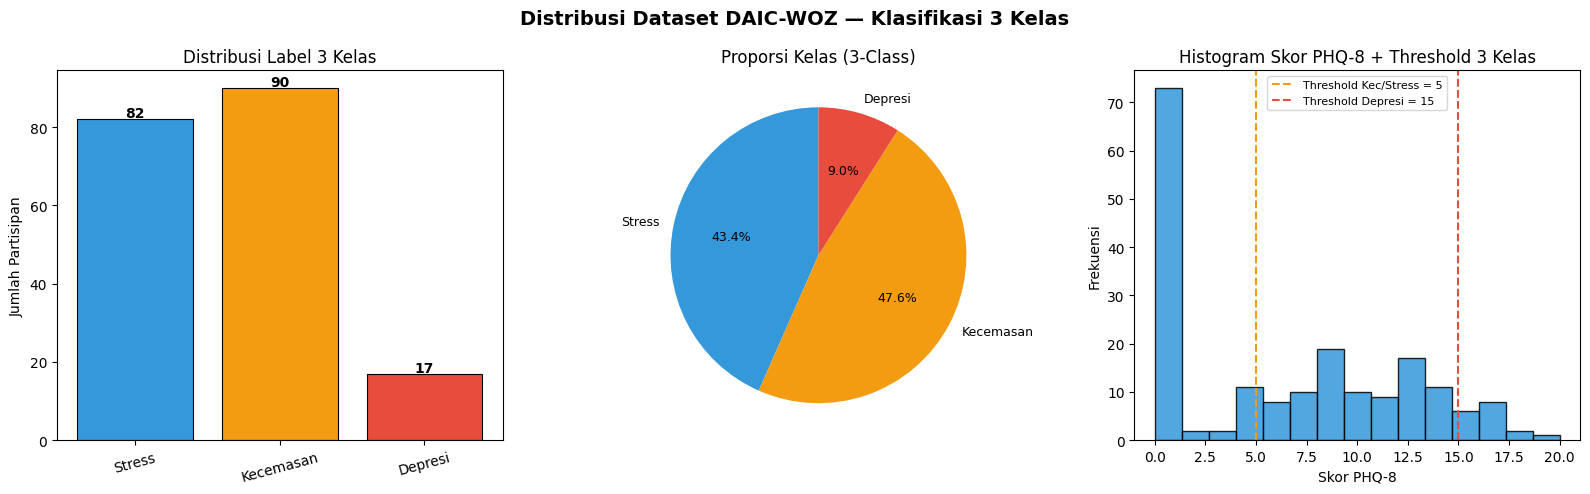

Visualisasi tersimpan.


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribusi Dataset DAIC-WOZ — Klasifikasi 3 Kelas', fontsize=14, fontweight='bold')

# Plot 1: Distribusi 3 Kelas: Stress | Kecemasan | Depresi
class_order  = [0, 1, 2]
class_labels = [CLASS_NAMES[k] for k in class_order]
class_counts = [int((df_labeled['label_3kelas'] == k).sum()) for k in class_order]
bars1 = axes[0].bar(class_labels, class_counts,
    color=['#3498db', '#f39c12', '#e74c3c'], edgecolor='black', linewidth=0.8)
axes[0].set_title('Distribusi Label 3 Kelas')
axes[0].set_ylabel('Jumlah Partisipan')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars1, class_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', fontweight='bold')

# Plot 2: Pie chart proporsi kelas
axes[1].pie(class_counts, labels=class_labels, autopct='%1.1f%%',
            colors=['#3498db', '#f39c12', '#e74c3c'], startangle=90,
            textprops={'fontsize': 9})
axes[1].set_title('Proporsi Kelas (3-Class)')

# Plot 3: Histogram Skor PHQ-8 dengan threshold
axes[2].hist(df_labeled['phq8_score'].dropna(), bins=15, color='#3498db',
             edgecolor='black', alpha=0.85)
axes[2].axvline(x=5,  color='#f39c12', linestyle='--', linewidth=1.5, label='Threshold Kec/Stress = 5')
axes[2].axvline(x=15, color='#e74c3c', linestyle='--', linewidth=1.5, label='Threshold Depresi = 15')
axes[2].set_title('Histogram Skor PHQ-8 + Threshold 3 Kelas')
axes[2].set_xlabel('Skor PHQ-8')
axes[2].set_ylabel('Frekuensi')
axes[2].legend(fontsize=8)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'p1_distribusi_dataset.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Visualisasi tersimpan.")


## 1.5 — Simpan Metadata ke CSV


In [16]:
OUTPUT_META = os.path.join(PROCESSED_DIR, 'daic_metadata.csv')

df_scan[['participant_id', 'folder_path', 'has_audio', 'has_transcript',
         'has_covarep', 'complete', 'phq8_score', 'label_3kelas', 'severity']].to_csv(
    OUTPUT_META, index=False
)

print(f"Metadata disimpan: {OUTPUT_META}")
print(f"\nRingkasan Akhir:")
print(f"  Total partisipan       : {len(df_scan)}")
print(f"  File lengkap           : {df_scan['complete'].sum()}")
print(f"  Berhasil dibaca label  : {df_labeled.shape[0]}")
for k, name in CLASS_NAMES.items():
    n = int((df_labeled['label_3kelas'] == k).sum())
    print(f"  Kelas {k} ({name}): {n}")

Metadata disimpan: d:\repositories\menthealth-ml\dataset\processed\daic_metadata.csv

Ringkasan Akhir:
  Total partisipan       : 189
  File lengkap           : 189
  Berhasil dibaca label  : 189
  Kelas 0 (Stress): 82
  Kelas 1 (Kecemasan): 90
  Kelas 2 (Depresi): 17
